# Seeing how KCC and COMMUS tailings compare

After exploring the implications of color patches in the KCC tailings facility, I found we can confidently recognize some chemical constituents such as iron and water. One feature seemed to potentially indicate the presence of autunite, the mineral precipitated in the presence of phosphate when deliberately removing uranium. It's speculative, but we may as well take a look at COMMUS (where we do not suspect uranium removal and autunite precipitation).

In [1]:
### Path adjustment so internal functions can be imported

import sys
import os # for file handling

# Add the parent directory to the system path
parent_dir = os.path.abspath(os.path.join(sys.path[0], ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

print("Parent directory added to sys.path:", parent_dir)    

Parent directory added to sys.path: /Users/rmanzuk/Princeton Dropbox/Ryan Manzuk/code/hyperspectral_u_sensing


In [2]:
### Function imports

import hyperspectral_u_sensing.processing.tanager_file_handling as tanager_file_handling
import hyperspectral_u_sensing.processing.hyperspectral_corrections as hyperspectral_corrections

In [3]:
### Package imports
import geopandas as gpd # for handling geospatial data
import h5py # the hyperspectral data is in hdf5 format
from rasterio.features import rasterize # to make masks from shapefiles
import matplotlib.pyplot as plt # gotta plot
import numpy as np # for numerical operations
from shapely import box 
from sklearn.decomposition import PCA
import rasterio as rio # for reading/writing geospatial raster data
import pandas as pd # for dataframes

In [ ]:
### Load in tailings patches and control shapefiles

# set a base path
base_path = '/Users/rmanzuk/Princeton Dropbox/Ryan Manzuk/drc_hyperspectral'

# sub paths for the tailings and control shapefiles
kcc_patches_subpath = 'traced_polygons/kcc_color_patches/kcc_colors.shp'
commus_patches_subpath = 'traced_polygons/commus_color_patches/commus_tails_colors.shp'

# load the shapefiles
kcc_patches_gdf = gpd.read_file(os.path.join(base_path, kcc_patches_subpath))
commus_patches_gdf = gpd.read_file(os.path.join(base_path, commus_patches_subpath))

# check the shapefiles as an output
print(kcc_patches_gdf.head())
print(commus_patches_gdf.head())


    color                                           geometry
0   white  POLYGON ((25.39682 -10.70169, 25.39738 -10.701...
1   brown  POLYGON ((25.39725 -10.7004, 25.39758 -10.7006...
2  yellow  POLYGON ((25.39776 -10.69898, 25.39824 -10.698...
3   brown  POLYGON ((25.39984 -10.70218, 25.39988 -10.702...
4     tan  POLYGON ((25.40076 -10.70372, 25.40069 -10.703...
    color                                           geometry
0  yellow  POLYGON ((25.41375 -10.76265, 25.41475 -10.760...
1  yellow  POLYGON ((25.41375 -10.76265, 25.41439 -10.762...
2   brown  POLYGON ((25.41439 -10.76251, 25.41476 -10.761...
3   brown  POLYGON ((25.41532 -10.76149, 25.41525 -10.761...
4   white  POLYGON ((25.41784 -10.76617, 25.41794 -10.766...
          type                                           geometry
0  tails_water  POLYGON ((25.40094 -10.69688, 25.40146 -10.696...
1      ore_pit  POLYGON ((25.42045 -10.70413, 25.41991 -10.703...
2      ore_pit  POLYGON ((25.42531 -10.7088, 25.42795 -10.7084...
3   

In [5]:
### Load in the hyperspectral data

# sub path for the kolwezi hyperspectral data
im_subpath = 'tanager_ims_drc/commus-order_tan-ortho-radiance_20250625'
im_path = os.path.join(base_path, im_subpath)

# search through the subdirectories for hdf5 file and the metadata.json file
scene_path, metadata_path = tanager_file_handling.find_subpaths(im_path)

# load the hyperspectral data
scene_file = h5py.File(scene_path, 'r')
scene_key = tanager_file_handling.scene_key(True)
rad_array, rad_attrs = tanager_file_handling.load_radiance(scene_file, scene_key)
wavelengths = rad_attrs['wavelengths']

# print the shape of the radiance array as a check
print("Radiance array shape:", rad_array.shape)
print("Radiance array attributes:", rad_attrs)

Radiance array shape: (426, 658, 775)
Radiance array attributes: {'Unit': 'W/(m^2 sr um)', '_FillValue': np.float32(-9999.0), 'applied_radiometric_coefficients': array([0.24117877, 0.19664247, 0.12794702, 0.10599381, 0.0785861 ,
       0.06810818, 0.05935678, 0.04755091, 0.04190101, 0.03722739,
       0.03394626, 0.0303052 , 0.02826379, 0.02598685, 0.02387025,
       0.02336355, 0.02251674, 0.02208806, 0.02204469, 0.02220925,
       0.02168082, 0.02049176, 0.01993347, 0.01987995, 0.01913034,
       0.01838925, 0.01796245, 0.01744622, 0.01674083, 0.01709536,
       0.01676122, 0.01611635, 0.01537274, 0.01469532, 0.0143942 ,
       0.01404121, 0.01360779, 0.01338364, 0.01328742, 0.01275896,
       0.01256888, 0.01229605, 0.01184709, 0.01151312, 0.01140921,
       0.01112384, 0.01085087, 0.01073875, 0.01054627, 0.01030221,
       0.0100322 , 0.01017956, 0.01043109, 0.01048737, 0.01056168,
       0.01062509, 0.01038046, 0.01180799, 0.01294908, 0.01158617,
       0.01024127, 0.01051945, 0.0

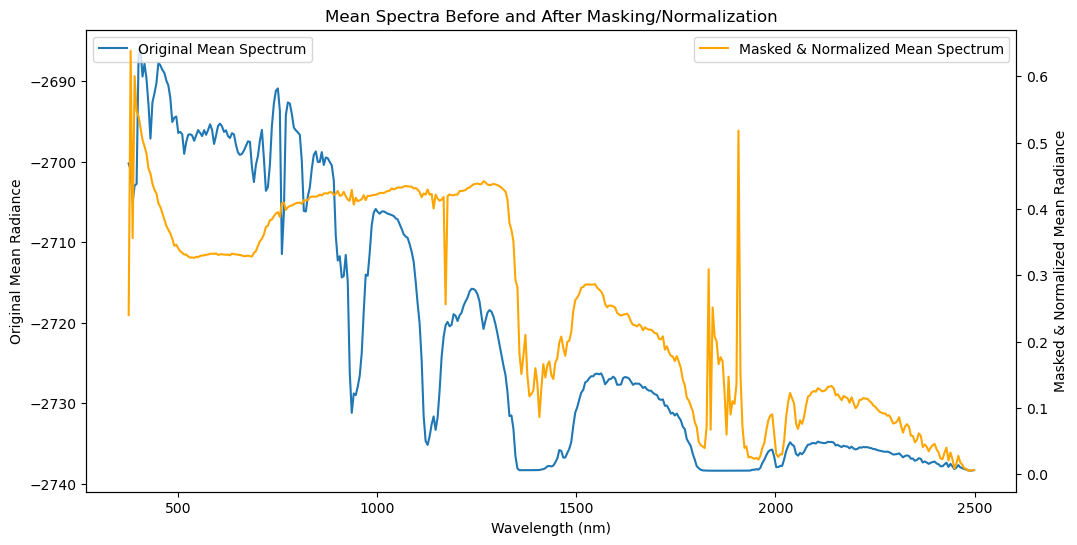

In [6]:
### normalize the radiance data, and collect the set of wavelengths that may be most atmospherically impacted

# need the mean spectrum to feed into the band function
mean_spectrum = np.mean(rad_array, axis=(1,2))

# make the bad band mask and associated bits
bad_mask = hyperspectral_corrections.tanager_bad_band_mask(rad_attrs['wavelengths'],
                          spectrum=mean_spectrum,
                          pad_nm=20)
## Not going to use the bad band mask for now, but keeping it here for future reference if needed

# take care of the no data values
no_data_val = rad_attrs['_FillValue']
no_data_mask = np.any(rad_array == no_data_val, axis=0)
rad_array[:, no_data_mask] = np.nan

# use the function to max normalize each band
rad_array_norm = hyperspectral_corrections.band_max_norm(rad_array)

# and make a new mean spectrum
normalized_mean_spectrum = np.nanmean(rad_array_norm, axis=(1,2))

# plot both mean spectra to check on a double y axis plot
plt.figure(figsize=(12, 6))
plt.plot(wavelengths, mean_spectrum, label='Original Mean Spectrum')
# double y axis plot
ax1 = plt.gca()
ax2 = ax1.twinx()
ax2.plot(wavelengths, normalized_mean_spectrum, color='orange', label='Masked & Normalized Mean Spectrum')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Original Mean Radiance')
ax2.set_ylabel('Masked & Normalized Mean Radiance')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Mean Spectra Before and After Masking/Normalization')
plt.show()

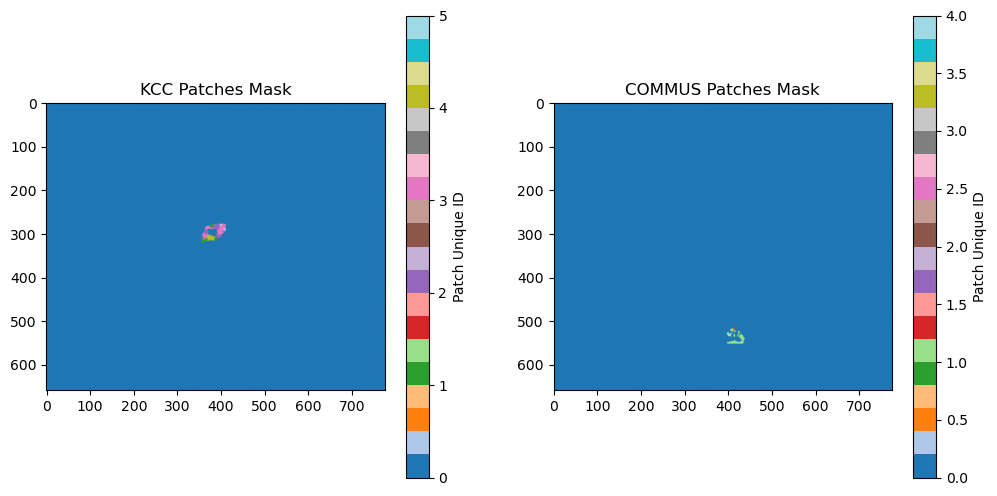

In [9]:
### assemble masks for the tailings patches and control color patches

# some custom functions to get geo-referencing info from the metadata
metadata = tanager_file_handling.h5_metadata(scene_file)
georef_info = tanager_file_handling.extract_georef_info(metadata)
ref_transform = tanager_file_handling.build_affine_transform(georef_info)
ref_crs = tanager_file_handling.build_crs(georef_info)
ref_shape = (georef_info['YDim'], georef_info['XDim'])
    
# double check the CRS of the polygons
if kcc_patches_gdf.crs != ref_crs:
    kcc_patches_gdf = kcc_patches_gdf.to_crs(ref_crs)

if commus_patches_gdf.crs != ref_crs:
    commus_patches_gdf = commus_patches_gdf.to_crs(ref_crs)

# also assign each polygon a unique ID, so we can track them in the rasterized mask
# start with list of unique patch colors and control types
unique_kcc_colors = kcc_patches_gdf['color'].unique().tolist()
unique_commus_colors = commus_patches_gdf['color'].unique().tolist()


# create a mapping from color/type to unique ID
kcc_color_to_id = {color: idx + 1 for idx, color in enumerate(unique_kcc_colors)}
commus_color_to_id = {color: idx + 1 for idx, color in enumerate(unique_commus_colors)}

# add a new column to each geodataframe with the unique IDs
kcc_patches_gdf['unique_id'] = kcc_patches_gdf['color'].map(kcc_color_to_id)
commus_patches_gdf['unique_id'] = commus_patches_gdf['color'].map(commus_color_to_id)

# rasterize the patches
kcc_patches_shapes = ((geom, value) for geom, value in zip(kcc_patches_gdf.geometry, kcc_patches_gdf.unique_id))
kcc_patches_mask = rasterize(shapes=kcc_patches_shapes,
                         out_shape=ref_shape,
                         transform=ref_transform,
                         fill=0,
                         dtype='uint8')
commus_patches_shapes = ((geom, value) for geom, value in zip(commus_patches_gdf.geometry, commus_patches_gdf.unique_id))
commus_patches_mask = rasterize(shapes=commus_patches_shapes,
                         out_shape=ref_shape,
                         transform=ref_transform,
                         fill=0,    
                         dtype='uint8')


# show the masks as a check
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(kcc_patches_mask, cmap='tab20')
plt.title('KCC Patches Mask')
plt.colorbar(label='Patch Unique ID')
plt.subplot(1, 2, 2)
plt.imshow(commus_patches_mask, cmap='tab20')
plt.title('COMMUS Patches Mask')
plt.colorbar(label='Patch Unique ID') 
plt.show()

In [12]:
### now we'll assemble a dataframe with the spectra from each patch and control area, labeled by their color/type and listing pixel locations

# initialize empty lists to hold the data
kcc_color_type = []
kcc_rows = []
kcc_cols = []
kcc_spectra = []

commus_color_type = []
commus_rows = []
commus_cols = []
commus_spectra = []

# loop through each kcc color
for color, uid in kcc_color_to_id.items():
    # find the pixel locations for this patch color
    rows, cols = np.where(kcc_patches_mask == uid)
    for r, c in zip(rows, cols):
        kcc_color_type.append(color)
        kcc_rows.append(r)
        kcc_cols.append(c)
        kcc_spectra.append(rad_array_norm[:, r, c])

# create a dataframe from the collected data
kcc_data = {
    'color_type': kcc_color_type,
    'row': kcc_rows,
    'col': kcc_cols,
    'spectrum': kcc_spectra
}

kcc_spectra_df = pd.DataFrame(kcc_data)

# loop through each commus color
for color, uid in commus_color_to_id.items():
    # find the pixel locations for this patch color
    rows, cols = np.where(commus_patches_mask == uid)
    for r, c in zip(rows, cols):
        commus_color_type.append(color)
        commus_rows.append(r)
        commus_cols.append(c)
        commus_spectra.append(rad_array_norm[:, r, c])

# create a dataframe from the collected data
commus_data = {
    'color_type': commus_color_type,
    'row': commus_rows,
    'col': commus_cols,
    'spectrum': commus_spectra
}

commus_spectra_df = pd.DataFrame(commus_data)

# print the .head of the dataframe as a check
print(kcc_spectra_df.head())
print(commus_spectra_df.head())

  color_type  row  col                                           spectrum
0      white  278  382  [0.28228715, 0.7256049, 0.41603884, 0.7013257,...
1      white  278  383  [0.27433452, 0.75430703, 0.42176586, 0.726708,...
2      white  278  384  [0.26601586, 0.70732975, 0.38309512, 0.6992595...
3      white  279  378  [0.27804628, 0.75706995, 0.41511345, 0.7168538...
4      white  279  379  [0.29001915, 0.78366053, 0.43961078, 0.756242,...
  color_type  row  col                                           spectrum
0     yellow  516  408  [0.23558995, 0.63168436, 0.35731098, 0.6162938...
1     yellow  516  409  [0.23247609, 0.60768193, 0.3527704, 0.616058, ...
2     yellow  517  404  [0.21965207, 0.620637, 0.34349212, 0.5843014, ...
3     yellow  517  408  [0.2497081, 0.6471787, 0.3517933, 0.6071048, 0...
4     yellow  517  409  [0.24704927, 0.65171164, 0.34391627, 0.6063795...


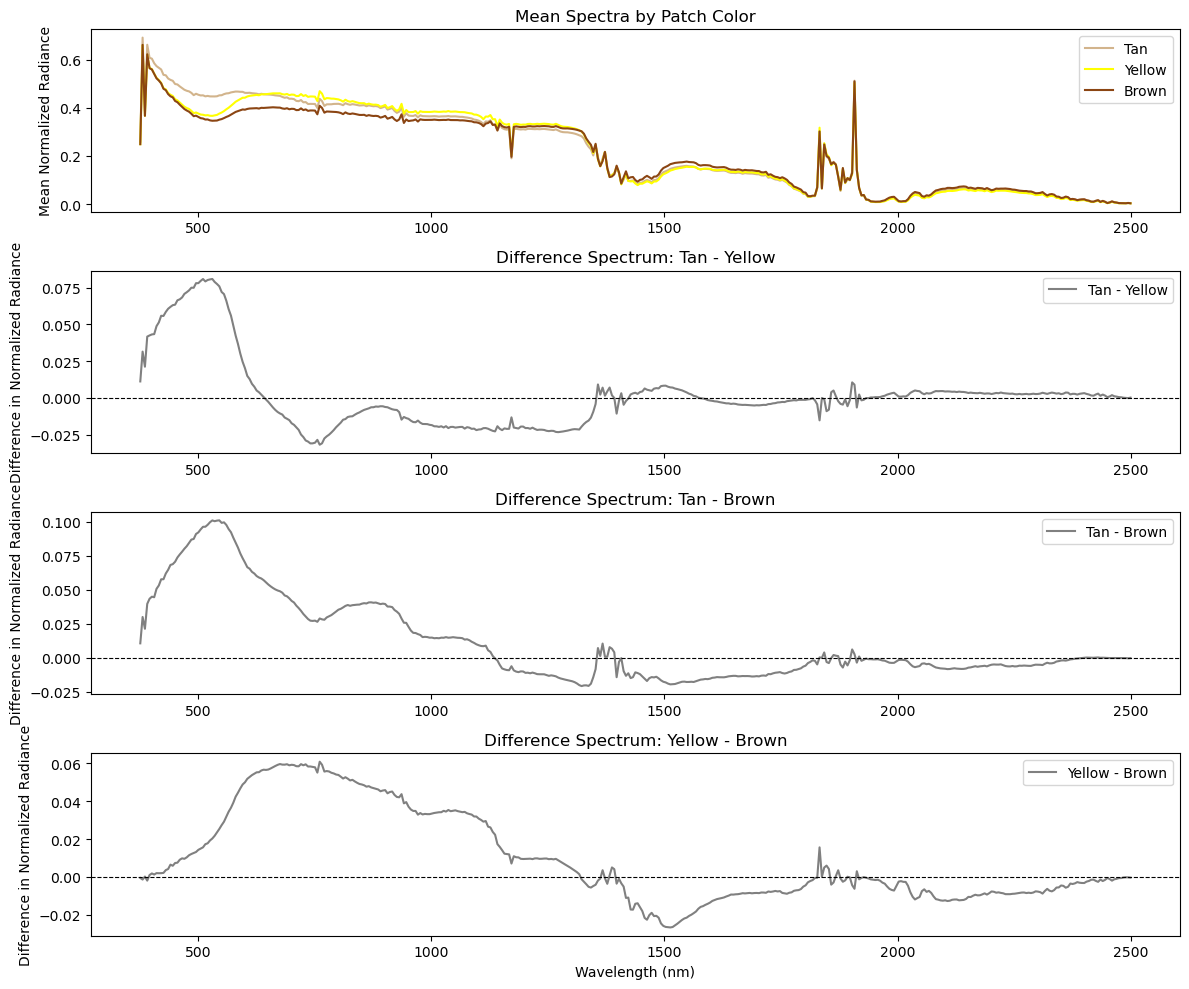

In [ ]:
### kcc difference spectra between brown, yellow, and tan patches to see what's causeing spectral differences

# get the mean spectra for each color patch
mean_spectra = {}
for color in kcc_color_to_id.keys():
    subset = kcc_spectra_df[kcc_spectra_df['color_type'] == color]
    mean_spectra[color] = np.mean(np.vstack(subset['spectrum'].values), axis=0)

# manually calculate difference spectra
tan_yellow_diff = mean_spectra['tan'] - mean_spectra['yellow']
tan_brown_diff = mean_spectra['tan'] - mean_spectra['brown']
yellow_brown_diff = mean_spectra['yellow'] - mean_spectra['brown']

# plot, first with the mean spectra in the top panel
fig,axs = plt.subplots(4, 1, figsize=(12, 10))
axs[0].plot(wavelengths, mean_spectra['tan'], label='Tan', color='tan')
axs[0].plot(wavelengths, mean_spectra['yellow'], label='Yellow', color='yellow')
axs[0].plot(wavelengths, mean_spectra['brown'], label='Brown', color='saddlebrown')
axs[0].set_title('KCC Mean Spectra by Patch Color')
axs[0].set_ylabel('Mean Normalized Radiance')
axs[0].legend() 

# now the difference spectra
axs[1].plot(wavelengths, tan_yellow_diff, label='Tan - Yellow', color='gray')
axs[1].set_title('Difference Spectrum: Tan - Yellow')
axs[1].set_ylabel('Difference in Normalized Radiance')
axs[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[1].legend()

axs[2].plot(wavelengths, tan_brown_diff, label='Tan - Brown', color='gray')
axs[2].set_title('Difference Spectrum: Tan - Brown')
axs[2].set_ylabel('Difference in Normalized Radiance')
axs[2].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[2].legend()

axs[3].plot(wavelengths, yellow_brown_diff, label='Yellow - Brown', color='gray')
axs[3].set_title('Difference Spectrum: Yellow - Brown')
axs[3].set_ylabel('Difference in Normalized Radiance')
axs[3].set_xlabel('Wavelength (nm)')
axs[3].axhline(0, color='black', linestyle='--', linewidth=0.8)
axs[3].legend()

plt.tight_layout()
plt.show()


In [17]:
### We want to compare these things to some reference spectra. To do that, run the script scripts/load_all_spectra.py

from hyperspectral_u_sensing.processing import load_all_spectra
df = load_all_spectra.load_all_spectra()

# normalize the reference spectra, being every column after the first one
for col in df.columns[1:]:
    df[col] = df[col] / np.nanmax(df[col])


/var/folders/gy/tnktbqnx0rv6k4vhfbk1m2hw0000gp/T/ipykernel_46698/2606144755.py:8: RuntimeWarning: All-NaN axis encountered
  df[col] = df[col] / np.nanmax(df[col])


In [18]:
# get the mean spectra for each color patch
kcc_mean_spectra = {}
for color in kcc_color_to_id.keys():
    subset = kcc_spectra_df[kcc_spectra_df['color_type'] == color]
    kcc_mean_spectra[color] = np.mean(np.vstack(subset['spectrum'].values), axis=0)

commus_mean_spectra = {}
for color in commus_color_to_id.keys():
    subset = commus_spectra_df[commus_spectra_df['color_type'] == color]
    commus_mean_spectra[color] = np.mean(np.vstack(subset['spectrum'].values), axis=0)

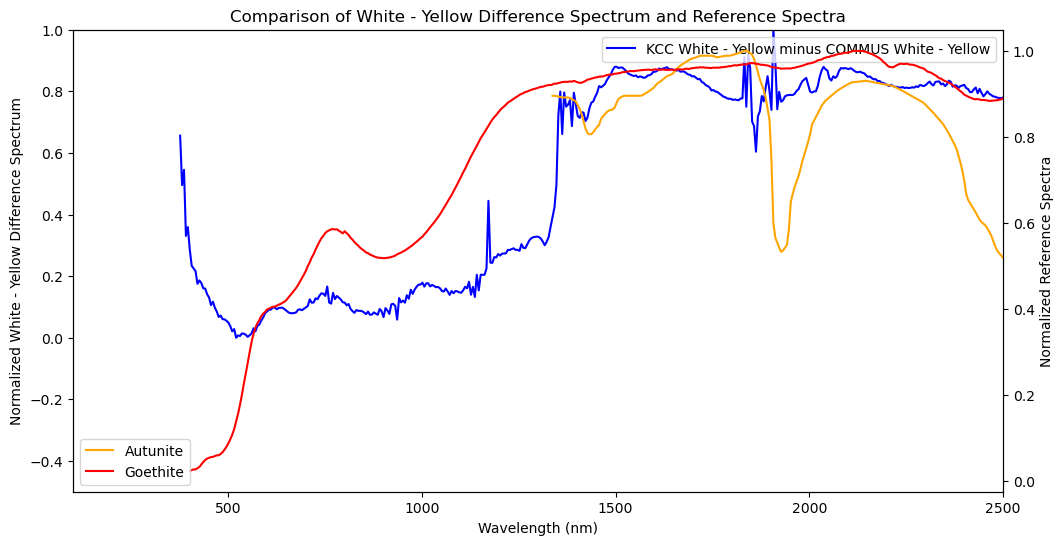

In [24]:
### plot both facility white - yellow difference spectra as well as some reference spectra

kcc_white_yellow_diff = kcc_mean_spectra['white'] - kcc_mean_spectra['yellow']
commus_white_yellow_diff = commus_mean_spectra['white'] - commus_mean_spectra['yellow']
diff_diff = commus_white_yellow_diff - kcc_white_yellow_diff

# stretch the diff diff between 0 and 1 for easier comparison
diff_diff = (diff_diff - np.nanmin(diff_diff)) / (np.nanmax(diff_diff) - np.nanmin(diff_diff))

ref_wavelengths = df['wavelengths'].values

# we'll do phosphoric acid, autunite, goethite
phosphoric_acid_spectrum = df['PhosphoricAcid'].values
autunite_spectrum = df['beiswenger2017_metaautunite'].values
goethite_spectrum = df['Goethite alpha Fe^3+O(OH)'].values
    
# the difference spectrum will be on one y axis, the references on the other
plt.figure(figsize=(12, 6))
plt.plot(wavelengths, diff_diff, label='KCC White - Yellow minus COMMUS White - Yellow', color='blue')
# make a double y axis plot
ax1 = plt.gca()
ax2 = ax1.twinx()
#ax2.plot(ref_wavelengths, phosphoric_acid_spectrum, label='Phosphoric Acid', color='green')
ax2.plot(ref_wavelengths, autunite_spectrum, label='Autunite', color='orange')
ax2.plot(ref_wavelengths, goethite_spectrum, label='Goethite', color='red')
ax1.set_ylabel('Normalized White - Yellow Difference Spectrum')
ax2.set_ylabel('Normalized Reference Spectra')
ax1.set_xlabel('Wavelength (nm)')
ax1.legend(loc='upper right')
ax2.legend(loc='lower left')
# just show wavelengths from 1500 to 2500 nm
ax1.set_xlim(100, 2500)
# and set the ylim for ax1 to 0 to 0.5
ax1.set_ylim(-0.5, 1)
plt.title('Comparison of White - Yellow Difference Spectrum and Reference Spectra')
plt.show()

